
### Opis zbioru danych

Zbiór danych zawiera informacje o transakcjach finansowych w technologii blockchain w ramach środowiska Open Metaverse.  
Zawiera łącznie **78 600 transakcji**, opisanych przy użyciu wielu cech, w tym:

- typy transakcji i ich kwoty,  
- profile aktywności użytkowników,  
- oceny ryzyka (`risk_score`),  
- dane czasowe (`timestamp`),  
- adresy nadawcy i odbiorcy,  
- kategorie transakcji,  
- regiony geograficzne i prefiksy IP.


---

### Cel projektu

Celem projektu jest zbudowanie systemu klasyfikacji ryzyka transakcji w metawersum z wykorzystaniem podejścia hybrydowego:  
łączącego rozmyte grupowanie Fuzzy C-Means z klasycznym uczeniem głębokim w postaci sieci neuronowej (FuzzySNN).  
Pozwala to nie tylko na klasyfikację, ale także na ocenę niepewności decyzji modelu.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import skfuzzy as fuzz

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [18]:
# Wczytanie danych o transakcjach w metaverse
df = pd.read_csv("metaverse_transactions_dataset.csv")
print(df.shape)
print(df.columns)
print(df.info())
print("\nBraki danych:\n", df.isnull().sum())


(78600, 14)
Index(['timestamp', 'hour_of_day', 'sending_address', 'receiving_address',
       'amount', 'transaction_type', 'location_region', 'ip_prefix',
       'login_frequency', 'session_duration', 'purchase_pattern', 'age_group',
       'risk_score', 'anomaly'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78600 entries, 0 to 78599
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          78600 non-null  object 
 1   hour_of_day        78600 non-null  int64  
 2   sending_address    78600 non-null  object 
 3   receiving_address  78600 non-null  object 
 4   amount             78600 non-null  float64
 5   transaction_type   78600 non-null  object 
 6   location_region    78600 non-null  object 
 7   ip_prefix          78600 non-null  float64
 8   login_frequency    78600 non-null  int64  
 9   session_duration   78600 non-null  int64  
 10  purchase_pattern   7

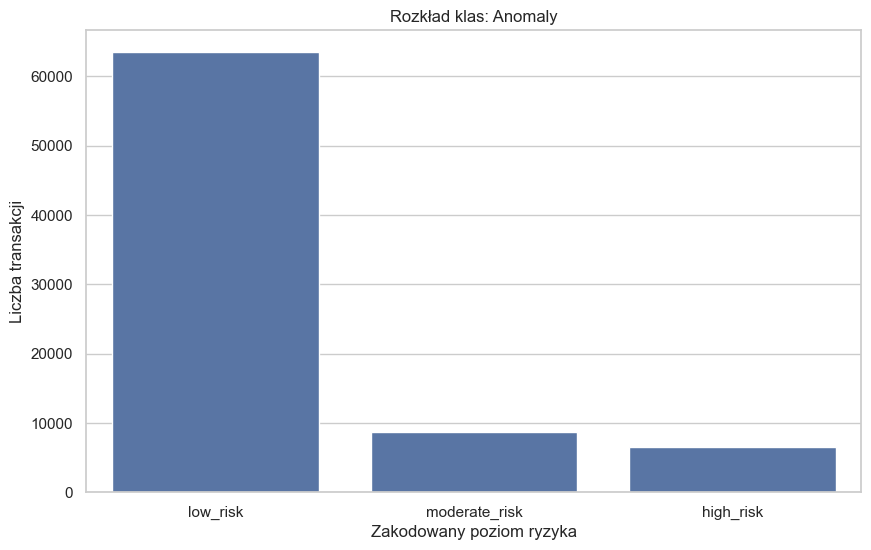

In [19]:
# Wizualizacja rozkładu klas ryzyka
sns.countplot(x='anomaly', data=df)
plt.title('Rozkład klas: Anomaly')
plt.xlabel('Zakodowany poziom ryzyka')
plt.ylabel('Liczba transakcji')
plt.show()

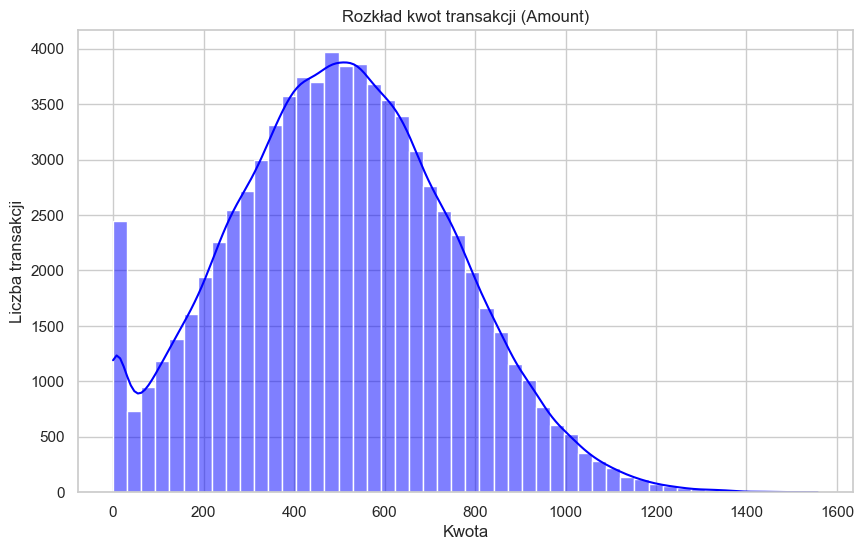

In [20]:
sns.histplot(df['amount'], bins=50, kde=True, color='blue')
plt.title('Rozkład kwot transakcji (Amount)')
plt.xlabel('Kwota')
plt.ylabel('Liczba transakcji')
plt.show()

In [ ]:

print(df.info())
print("\nBraki danych:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78600 entries, 0 to 78599
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          78600 non-null  object 
 1   hour_of_day        78600 non-null  int64  
 2   sending_address    78600 non-null  object 
 3   receiving_address  78600 non-null  object 
 4   amount             78600 non-null  float64
 5   transaction_type   78600 non-null  object 
 6   location_region    78600 non-null  object 
 7   ip_prefix          78600 non-null  float64
 8   login_frequency    78600 non-null  int64  
 9   session_duration   78600 non-null  int64  
 10  purchase_pattern   78600 non-null  object 
 11  age_group          78600 non-null  object 
 12  risk_score         78600 non-null  float64
 13  anomaly            78600 non-null  object 
dtypes: float64(3), int64(3), object(8)
memory usage: 8.4+ MB
None

Braki danych:
 timestamp            0
hour_of_day      

In [ ]:
data = df.copy()
categorical_cols = ['transaction_type', 'location_region', 'purchase_pattern', 'age_group', 'anomaly']
encoders = {}
for col in categorical_cols:
    enc = LabelEncoder()
    data[col] = enc.fit_transform(data[col])
    encoders[col] = enc

data.drop(['timestamp', 'sending_address', 'receiving_address'], axis=1, inplace=True)

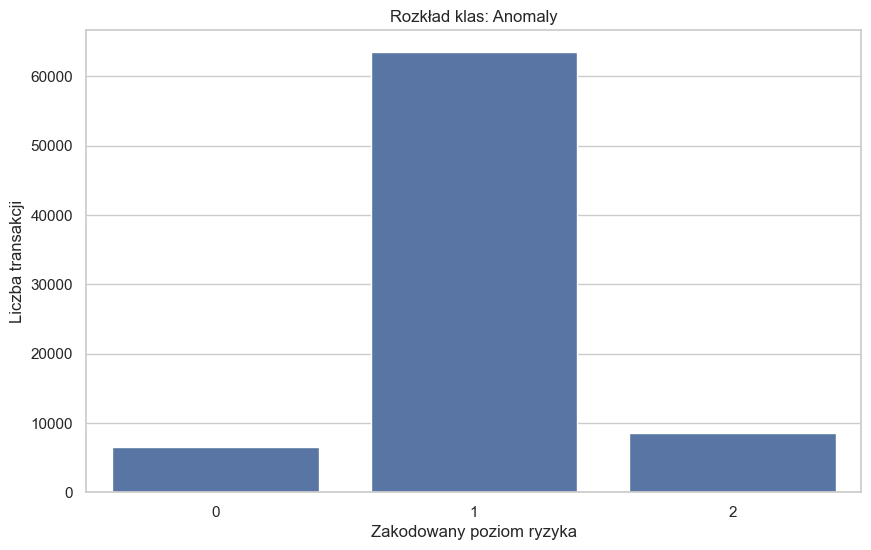

In [23]:
# Wizualizacja rozkładu klas ryzyka
sns.countplot(x='anomaly', data=data)
plt.title('Rozkład klas: Anomaly')
plt.xlabel('Zakodowany poziom ryzyka')
plt.ylabel('Liczba transakcji')
plt.show()


# 1 - low , 2 - moderate , 0 - high

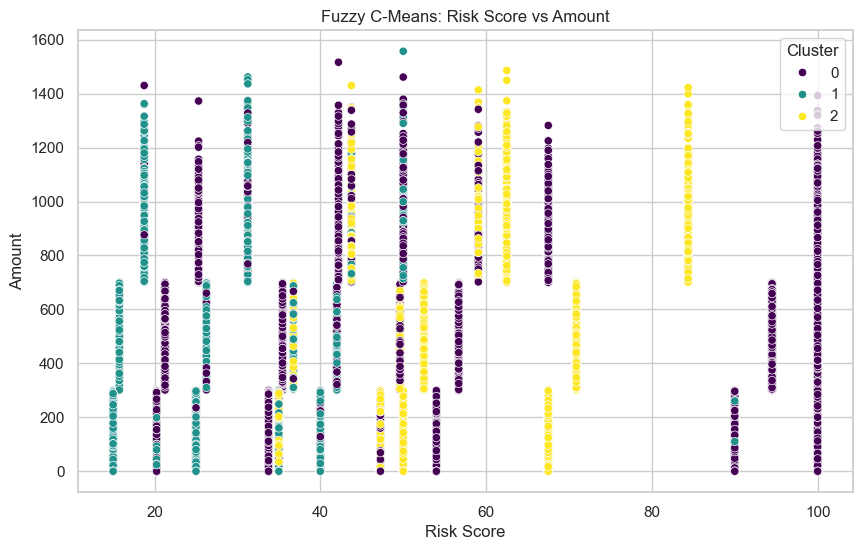

In [ ]:
# Skalowanie cech numerycznych do zakresu standaryzowanego
numerical_features = ['amount', 'risk_score', 'login_frequency', 'session_duration', 'hour_of_day']
X = df[numerical_features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

data_fcm = X_scaled.T  

n_clusters = 3
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data_fcm, c=n_clusters, m=2, error=0.005, maxiter=1000, init=None)

cluster_labels = np.argmax(u, axis=0)
df['fuzzy_cluster'] = cluster_labels

plt.figure(figsize=(10,6))
sns.scatterplot(x=df['risk_score'], y=df['amount'], hue=df['fuzzy_cluster'], palette='viridis')
plt.title('Fuzzy C-Means: Risk Score vs Amount')
plt.xlabel('Risk Score')
plt.ylabel('Amount')
plt.legend(title='Cluster')
plt.show()


Wykres przedstawia wyniki klasteryzacji metodą Fuzzy C-Means na podstawie dwóch zmiennych: Risk Score (ryzyko) i Amount (kwota). Każdy punkt reprezentuje pojedynczą obserwację, a kolor wskazuje przynależność do jednego z trzech klastrów. Klaster 0 (fioletowy) skupia się głównie wokół średnich i wysokich kwot oraz wyższych wartości ryzyka – może reprezentować klientów o większych transakcjach i wyższym ryzyku. Klaster 1 (zielono-niebieski) dominuje przy niskim Risk Score i obejmuje zróżnicowane kwoty, często niższe – co może wskazywać na klientów niskiego ryzyka, ale o mniejszej aktywności finansowej. Klaster 2 (żółty) występuje w zakresie średniego ryzyka i obejmuje głównie niskie do średnich kwoty – może dotyczyć klientów o niepewnym profilu. Metoda Fuzzy C-Means pozwala na bardziej elastyczną segmentację, uwzględniającą nieostre granice między grupami, co dobrze oddaje złożoność analizowanych danych.

In [ ]:
# Podział danych na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, u.T, test_size=0.2, random_state=42
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [ ]:
# Definicja klasy modelu FuzzySNN – sieć neuronowa
class FuzzySNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(FuzzySNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.layers(x)

input_dim = X_train.shape[1]
output_dim = n_clusters
model = FuzzySNN(input_dim, output_dim)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 50
for epoch in range(epochs):
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/50, Loss: 0.0039
Epoch 2/50, Loss: 0.0003
Epoch 3/50, Loss: 0.0001
Epoch 4/50, Loss: 0.0001
Epoch 5/50, Loss: 0.0001
Epoch 6/50, Loss: 0.0001
Epoch 7/50, Loss: 0.0001
Epoch 8/50, Loss: 0.0001
Epoch 9/50, Loss: 0.0001
Epoch 10/50, Loss: 0.0001
Epoch 11/50, Loss: 0.0000
Epoch 12/50, Loss: 0.0000
Epoch 13/50, Loss: 0.0000
Epoch 14/50, Loss: 0.0000
Epoch 15/50, Loss: 0.0000
Epoch 16/50, Loss: 0.0000
Epoch 17/50, Loss: 0.0000
Epoch 18/50, Loss: 0.0000
Epoch 19/50, Loss: 0.0000
Epoch 20/50, Loss: 0.0000
Epoch 21/50, Loss: 0.0000
Epoch 22/50, Loss: 0.0000
Epoch 23/50, Loss: 0.0000
Epoch 24/50, Loss: 0.0000
Epoch 25/50, Loss: 0.0000
Epoch 26/50, Loss: 0.0000
Epoch 27/50, Loss: 0.0000
Epoch 28/50, Loss: 0.0000
Epoch 29/50, Loss: 0.0000
Epoch 30/50, Loss: 0.0000
Epoch 31/50, Loss: 0.0000
Epoch 32/50, Loss: 0.0000
Epoch 33/50, Loss: 0.0000
Epoch 34/50, Loss: 0.0000
Epoch 35/50, Loss: 0.0000
Epoch 36/50, Loss: 0.0000
Epoch 37/50, Loss: 0.0000
Epoch 38/50, Loss: 0.0000
Epoch 39/50, Loss: 0.

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).numpy()

from sklearn.metrics import mean_squared_error
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"\nTest MSE: {mse_test:.6f}")


Test MSE: 0.000022


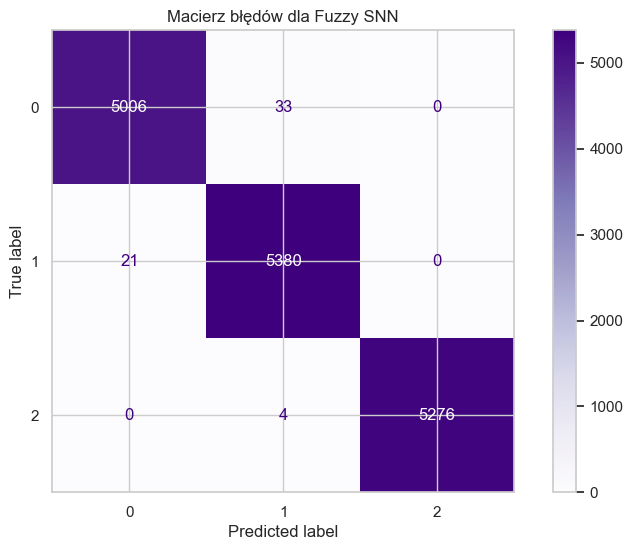

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
 
y_test_np = y_test_tensor.numpy()
 
# Przypisanie klas (najwyższa przynależność)
y_pred_classes = np.argmax(y_pred_test, axis=1)
y_true_classes = np.argmax(y_test_np, axis=1)
 
# Macierz błędów
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')
plt.title("Macierz błędów dla Fuzzy SNN")
plt.show()

Macierz błędów dla modelu Fuzzy SNN pokazuje bardzo wysoką skuteczność klasyfikacji – zdecydowana większość próbek została poprawnie przypisana do odpowiednich klas, co widać po dominujących wartościach na przekątnej macierzy. Model poprawnie sklasyfikował 5006 przypadków jako klasę 0, 5380 jako klasę 1 i 5276 jako klasę 2. Błędy klasyfikacji są nieliczne: klasa 0 została mylnie rozpoznana jako klasa 1 w 33 przypadkach, klasa 1 jako klasa 0 w 21 przypadkach, a klasa 2 jako klasa 1 tylko 4 razy. Brak błędów między klasą 0 a 2 oraz klasą 1 a 2 świadczy o dobrej separowalności tych grup. Ogólnie, model wykazuje bardzo wysoką precyzję i stabilność w odwzorowywaniu rozmytych przynależności klasowych.

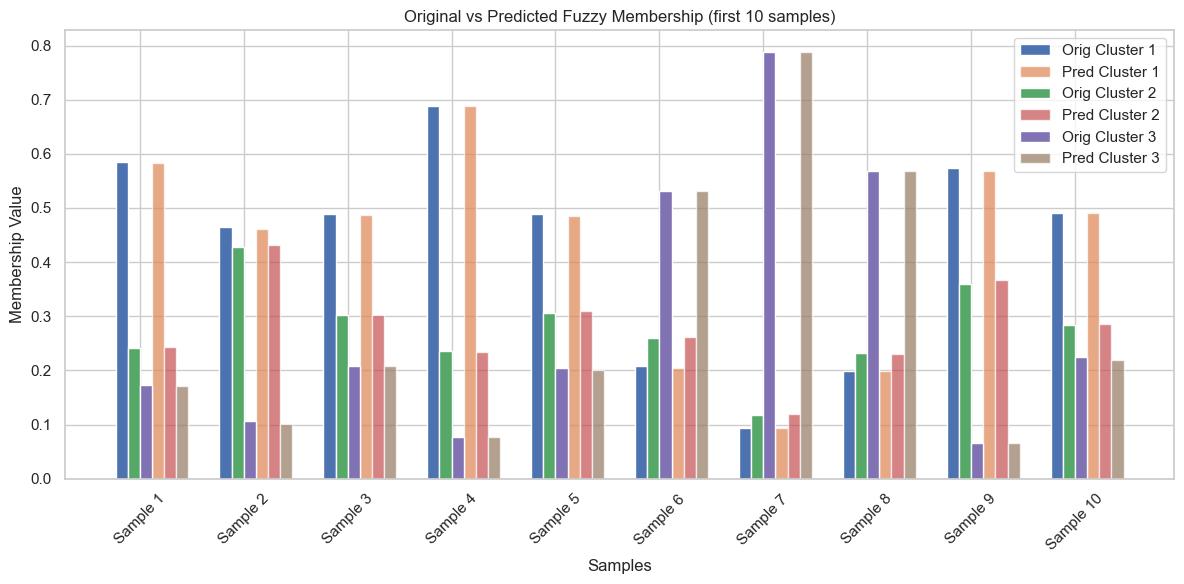

In [ ]:
original_membership = y_test  
predicted_membership = y_pred_test

N = 10
labels = [f'Sample {i+1}' for i in range(N)]
clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
x = np.arange(N)
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

for i in range(3):
    ax.bar(x - width/2 + i*(width/3), original_membership[:N, i], width/3, label=f'Orig {clusters[i]}')
    ax.bar(x + width/2 + i*(width/3), predicted_membership[:N, i], width/3, label=f'Pred {clusters[i]}', alpha=0.7)

ax.set_xlabel('Samples')
ax.set_ylabel('Membership Value')
ax.set_title('Original vs Predicted Fuzzy Membership (first 10 samples)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

Wykres przedstawia porównanie oryginalnych i przewidywanych wartości przynależności do klastrów dla pierwszych 10 próbek w analizie Fuzzy C-Means. Dla każdej próbki pokazano, z jakim stopniem (od 0 do 1) należy ona do trzech klastrów – osobno dla wartości rzeczywistych (słupki niebieskie, zielone i fioletowe) oraz przewidywanych przez model (słupki pomarańczowe, czerwone i szare).
W większości przypadków model dobrze odwzorowuje strukturę rozmytej przynależności – przewidywane wartości są zbliżone do oryginalnych, a układ dominujących klastrów pozostaje zgodny. Widoczne są jednak niewielkie różnice w niektórych próbkach, np. w próbce 4 i 7, gdzie przynależność do dominującego klastra została lekko przeszacowana lub niedoszacowana. Mimo tych odchyleń, model zachowuje ogólny charakter segmentacji, co świadczy o jego skuteczności.

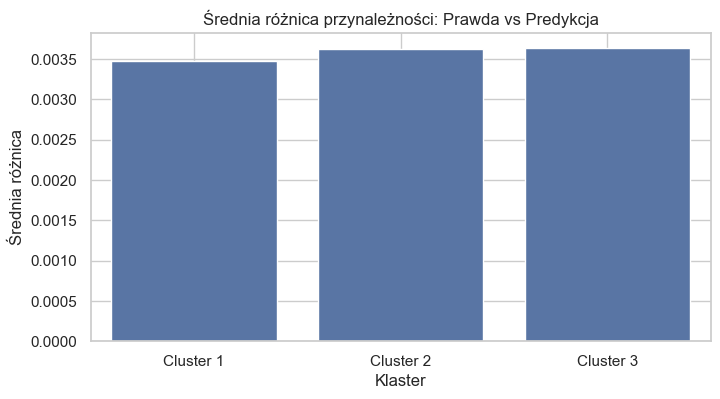

In [ ]:
import seaborn as sns
 
y_test_np = y_test_tensor.numpy()
diff = np.abs(y_test_np - y_pred_test)
mean_diff = np.mean(diff, axis=0)
 
plt.figure(figsize=(8, 4))
sns.barplot(x=[f'Cluster {i+1}' for i in range(len(mean_diff))], y=mean_diff)
plt.title('Średnia różnica przynależności: Prawda vs Predykcja')
plt.ylabel('Średnia różnica')
plt.xlabel('Klaster')
plt.grid(True)
plt.show()

Wykres przedstawia średnią różnicę między rzeczywistymi a przewidywanymi przynależnościami do klastrów w modelu Fuzzy SNN. Niskie wartości różnic (około 0.0034) we wszystkich trzech klastrach wskazują, że model bardzo precyzyjnie odwzorowuje stopień przynależności próbek do odpowiednich grup. Brak wyraźnych różnic między klastrami sugeruje równą skuteczność modelu w każdej klasie. Oznacza to, że Fuzzy SNN nie tylko trafnie klasyfikuje próbki, ale również dobrze odtwarza rozmytą strukturę danych, co potwierdza jego wysoką jakość i przydatność w zadaniach wymagających interpretowalności i precyzji przynależności.

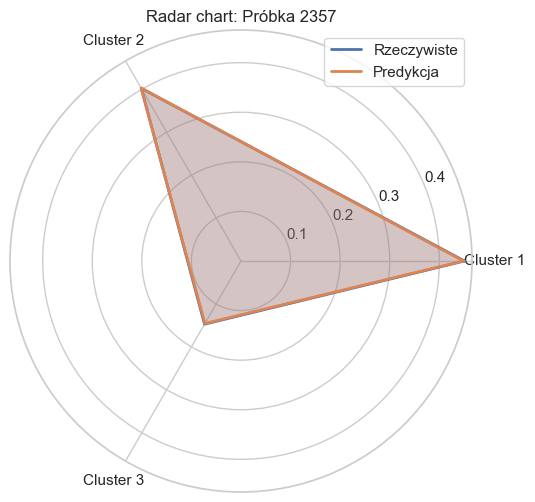

In [ ]:
import numpy as np
 
sample_idx = 2356
true_vals = y_test_tensor[sample_idx].numpy()
pred_vals = y_pred_test[sample_idx]
 
labels = [f'Cluster {i+1}' for i in range(len(true_vals))]
angles = np.linspace(0, 2 * np.pi, len(true_vals), endpoint=False).tolist()
angles += angles[:1]
 
true_vals = np.append(true_vals, true_vals[0])
pred_vals = np.append(pred_vals, pred_vals[0])
 
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, true_vals, label='Rzeczywiste', linewidth=2)
ax.fill(angles, true_vals, alpha=0.25)
ax.plot(angles, pred_vals, label='Predykcja', linewidth=2)
ax.fill(angles, pred_vals, alpha=0.25)
 
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title(f'Radar chart: Próbka {sample_idx+1}')
plt.legend(loc='upper right')
plt.show()

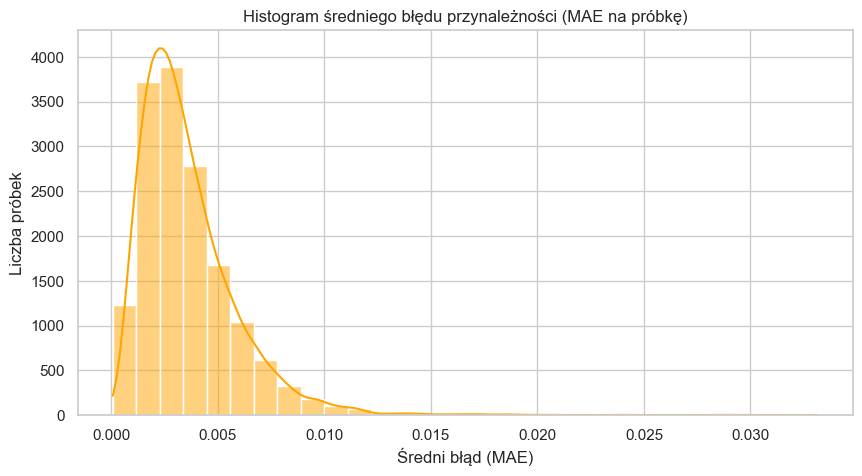

In [ ]:
mae_per_sample = np.mean(np.abs(y_test_tensor.numpy() - y_pred_test), axis=1)
 
plt.figure(figsize=(10, 5))
sns.histplot(mae_per_sample, bins=30, kde=True, color='orange')
plt.title('Histogram średniego błędu przynależności (MAE na próbkę)')
plt.xlabel('Średni błąd (MAE)')
plt.ylabel('Liczba próbek')
plt.grid(True)
plt.show()

Wykres przedstawia histogram średniego błędu bezwzględnego (MAE) między rzeczywistymi a przewidywanymi przynależnościami do klastrów dla każdej próbki. Większość próbek osiąga bardzo niski błąd – poniżej 0.005 – co świadczy o wysokiej precyzji modelu Fuzzy SNN w odwzorowywaniu rozmytej przynależności. Rozkład jest silnie skośny, z długim ogonem w prawo, co oznacza, że tylko niewielka liczba przypadków ma nieco większe odchylenia. Ogólnie wykres potwierdza, że model w zdecydowanej większości przypadków trafnie oddaje charakter fuzzy klastrów na poziomie pojedynczych próbek.

In [ ]:
# Podział danych na zbiór treningowy i testowy
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = data.drop('anomaly', axis=1)
y = data['anomaly']          

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))



Accuracy: 0.9939
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1906
           1       1.00      0.99      1.00     19198
           2       0.96      0.99      0.97      2476

    accuracy                           0.99     23580
   macro avg       0.98      0.99      0.99     23580
weighted avg       0.99      0.99      0.99     23580



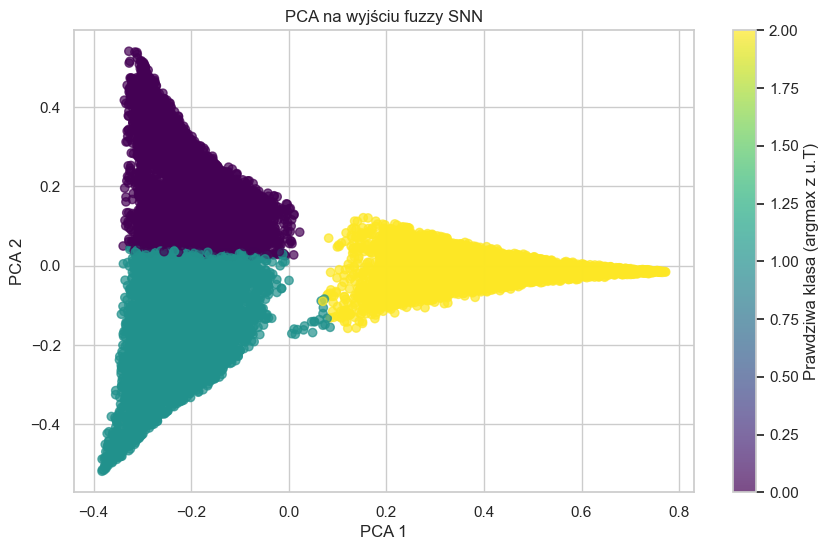

In [ ]:
from sklearn.decomposition import PCA
 
# Redukcja predykcji do 2D
pca = PCA(n_components=2)
reduced_preds = pca.fit_transform(y_pred_test)
 
# Klasy rzeczywiste z fuzzy SNN (u.T)
y_true_classes = np.argmax(y_test_tensor.numpy(), axis=1)
 
# Wykres PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_preds[:, 0], reduced_preds[:, 1], 
                      c=y_true_classes, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Prawdziwa klasa (argmax z u.T)")
plt.title("PCA na wyjściu fuzzy SNN")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

Ten wykres przedstawia dwuwymiarową projekcję danych wyjściowych modelu Fuzzy SNN za pomocą metody PCA (Principal Component Analysis). Każdy punkt reprezentuje jedną próbkę testową, a kolor odpowiada jej rzeczywistej klasie (czyli klasie, do której miała najwyższą przynależność w rozmytym klastrowaniu FCM).
Widoczny na wykresie wyraźny podział punktów na trzy skupiska sugeruje, że fuzzy SNN skutecznie nauczył się odwzorowywać strukturę klas w danych — nawet po zredukowaniu wymiarowości do 2D klastry są dobrze odseparowane. To potwierdza, że model nie tylko minimalizuje błąd, ale również zachowuje spójną reprezentację klas, co jest istotne w interpretowalnych systemach klasyfikacji rozmytej. W szczególności brak znaczącego nakładania się klastrów potwierdza wysoką jakość odwzorowania relacji klasowych przez model.


### Podsumowanie projektu

W niniejszym projekcie zaprezentowano hybrydowe podejście do klasyfikacji ryzyka transakcji w środowisku metawersum, łączące rozmyte grupowanie (Fuzzy C-Means, FCM) z nadzorowanym uczeniem głębokim przy użyciu sztucznej sieci neuronowej (FuzzySNN).

Zastosowanie algorytmu Fuzzy C-Means umożliwiło identyfikację ukrytych struktur w danych bez konieczności posiadania uprzednio zdefiniowanych etykiet klasowych. Jego kluczową cechą jest przypisywanie danych do wielu klastrów z określonymi stopniami przynależności, co odzwierciedla niepewność i rozmyty charakter realnych zjawisk – w tym przypadku ryzyka finansowego. Takie probabilistyczne podejście stanowi bardziej elastyczną alternatywę wobec klasycznego twardego przypisania do jednej klasy.

Na podstawie stopni przynależności wygenerowanych przez FCM opracowano nadzorowany model FuzzySNN, którego celem było odwzorowanie rozmytych etykiet w formie ciągłych wyjść sieci neuronowej. Architektura modelu oparta na warstwach gęstych z funkcjami aktywacji ReLU i Sigmoid umożliwiła efektywne modelowanie nieliniowych zależności między cechami a poziomem ryzyka.

Porównując oba podejścia:

- FCM działa w pełni nienadzorowanie i pozwala na intuicyjną interpretację przynależności do klastrów, jednak nie potrafi generalizować do nowych danych bez ponownego uczenia.

- FuzzySNN umożliwia predykcję rozmytych przynależności dla nowych obserwacji i może być trenowany iteracyjnie w sposób bardziej odporny na szum i nadmiarowość cech.

Podsumowując, połączenie metod rozmytego grupowania z głębokim uczeniem nadzorowanym tworzy elastyczny, skalowalny i interpretowalny system klasyfikacji. Takie podejście jest szczególnie wartościowe w dziedzinach wymagających uwzględniania niepewności, jak analiza ryzyka, wykrywanie oszustw czy cyberbezpieczeństwo w środowiskach zdecentralizowanych.

Model KNN, będący jednym z najprostszych klasyfikatorów nadzorowanych, został wykorzystany jako punkt odniesienia. Jego zaletą jest intuicyjność oraz brak potrzeby trenowania parametrów modelu, jednak jego skuteczność zależy w dużym stopniu od metryki odległości, liczby sąsiadów oraz jakości odwzorowania przestrzeni cech. W zastosowanym wariancie (z k=5), KNN osiągnął umiarkowaną dokładność klasyfikacji, lecz wykazał ograniczoną zdolność do rozróżniania klas w warunkach częściowej niepewności lub nakładających się klas.

Podsumowując, KNN oferuje szybkie i łatwe wdrożenie, lecz wykazuje ograniczenia przy złożonych i niepewnych danych, charakterystycznych dla transakcji blockchain. Z kolei FuzzySNN, choć bardziej złożony obliczeniowo na etapie uczenia, zapewnia większą odporność, lepszą jakość predykcji oraz możliwość analizy niepewności klasyfikacyjnej. Tym samym podejście rozmyte stanowi istotny krok w kierunku bardziej zaawansowanych, wiarygodnych systemów analitycznych w środowiskach zdecentralizowanych.